In [2]:
import pandas as pd
df = pd.read_csv("movies_updated.csv")

In [4]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ï»¿name    4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


,year,score,votes,budget,gross
count,4000.000000,4000.000000,4.000000e+03,4.000000e+03,3.831000e+03
mean,1991.191500,6.321950,5.449450e+04,1.542740e+07,4.172202e+07
std,5.934529,0.977101,1.427738e+05,2.248639e+07,9.259504e+07
min,1980.000000,2.200000,5.100000e+01,0.000000e+00,3.090000e+02
25%,1986.000000,5.700000,4.300000e+03,0.000000e+00,2.835743e+06
50%,1991.000000,6.400000,1.300000e+04,7.000000e+06,1.183822e+07
75%,1996.000000,7.000000,4.500000e+04,2.100000e+07,3.560495e+07
max,2001.000000,9.300000,2.400000e+06,2.000000e+08,2.201647e+09


Questions
1. How many movies are in the dataset? <span style="color:red">4000 entries</span>
2. Which columns are numerical? <span style="color:red">five</span>
3. Which columns are categorical?  <span style="color:red">ten</span>

# Task 2: Number of Movies Released Each Year
1.Use Pandas to determine the number of movies released each year.
2.Create a line plot to visualize the trend.

In [5]:
#group rows by column and count movie names in each group
movies_per_year = df.groupby("year")["ï»¿name"].count()

print(movies_per_year)

year
1980     92
1981    113
1982    126
1983    144
1984    168
1985    200
1986    200
1987    200
1988    200
1989    200
1990    200
1991    200
1992    200
1993    200
1994    200
1995    200
1996    200
1997    200
1998    200
1999    200
2000    200
2001    157
Name: ï»¿name, dtype: int64


In [13]:
max_movies = 0
best_year = None

for year, count in movies_per_year.items():
    if count > max_movies:
        max_movies = count
        best_year = year

print("Year with most movies:", best_year)
print("Number of movies:", max_movies)

Year with most movies: 1985
Number of movies: 200


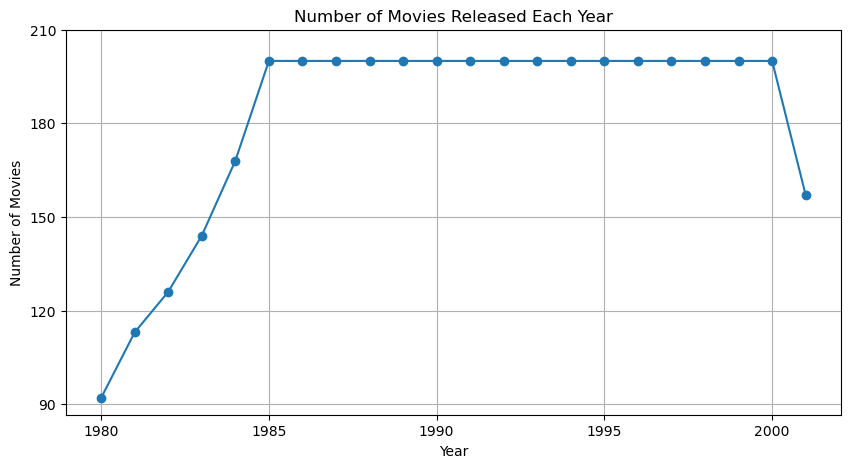

In [12]:
import matplotlib.pyplot as plt
import numpy as np

movies_per_year = df.groupby("year")["ï»¿name"].count()

plt.figure(figsize=(10, 5))
plt.plot(movies_per_year.index, movies_per_year.values, marker="o")


plt.yticks(
    np.arange(
        90,
        movies_per_year.max() + 30,
        30
    )
)


plt.title("Number of Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)

plt.show()

Questions
1. Which year has the most movies? <span style="color:red"> 1985</span>
2. Does the number of movies increase over time? <span style="color:red"> no <span style="color:red"> 
3. What trend do you observe? <span style="color:red"> The number of movies released does not generally decrease over time. It increases from 1980 to 1985, remains relatively stable until 2000, and then decreases in 2001</span>


# Task 3: Top 10 Movie Genres
Find the top 10 genres with the largest number of movies.
Create a vertical bar chart.
Questions
1. Which genre contains the most movies? comedy
2. Which genre contains the fewest movies among the top 10? mystery
3. Why is a bar chart suitable for this task?

Since genre is catagorical data it makes more sense to use a bar graph other methods are better for contious data (data that remains constant increases or decreases)

genre
Comedy       1355
Drama         807
Action        775
Crime         302
Adventure     231
Biography     175
Horror        158
Animation     113
Fantasy        33
Mystery        13
Name: count, dtype: int64


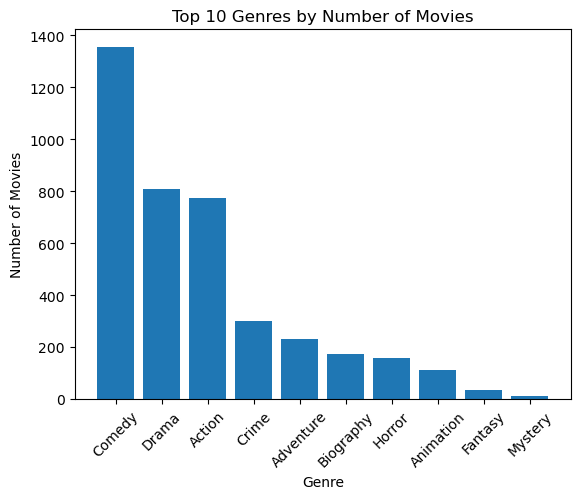

In [17]:
#sorts list and shows first 10 genres
top_10_genres = df["genre"].value_counts().head(10)

print(top_10_genres)


top_10_genres = df["genre"].value_counts().head(10)

plt.bar(top_10_genres.index, top_10_genres.values)

plt.title("Top 10 Genres by Number of Movies")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

In [20]:
max_genre = None
max_count = 0

min_genre = None
min_count = float('inf')

for genre, count in top_10_genres.items():
    if count > max_count:
        max_count = count
        max_genre = genre

    if count < min_count:
        min_count = count
        min_genre = genre

print("Most movies:", max_genre, max_count)
print("Fewest movies:", min_genre, min_count)

Most movies: Comedy 1355
Fewest movies: Mystery 13


# Task 4: Top 10 Directors
Find the top 10 directors with the largest number of movies.
Create a horizontal bar chart.
Questions
1. Which director produced the most movies?
    woody allen
4. Why is a horizontal bar chart more suitable than a vertical bar chart for this visualization?
   Horizontal bar charts seem better here because its a lot easier to read the names of the directors

In [21]:
top_10_director = df["director"].value_counts().head(10)


In [22]:
print(top_10_director)

director
Woody Allen         22
Directors           16
Barry Levinson      16
Clint Eastwood      16
Joel Schumacher     15
Walter Hill         15
Sidney Lumet        15
Ron Howard          14
Steven Spielberg    14
John Carpenter      14
Name: count, dtype: int64


In [26]:
max_d = None
max_count = 0


for director, count in top_10_director.items():
    if count > max_count:
        max_count = count
        max_d = director

print("Most movies:", max_d, max_count)


Most movies: Woody Allen 22


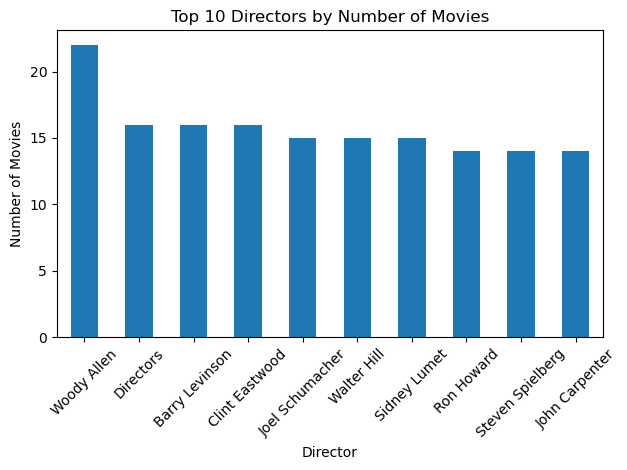

In [24]:
import matplotlib.pyplot as plt

top_10_director.plot(kind="bar")

plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

import matplotlib.pyplot as plt

plt.barh(top_10_director.index, top_10_director.values)

plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Director")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fruits = ['Apples', 'Bananas', 'Mango', 'Lemon']
sales = [400, 350, 300, 450]
plt.barh(fruits, sales)
plt.title('Fruit Sales')
plt.xlabel('Fruits')
plt.ylabel('Sales')
plt.show()

# Task 5: Distribution of Movie Ratings
Using the score column, create a histogram.
Questions
1. Which score range contains the largest number of movies?
2. Are most movies highly rated?
3. Are low-rated movies common?
4. What does the histogram tell you about movie ratings?

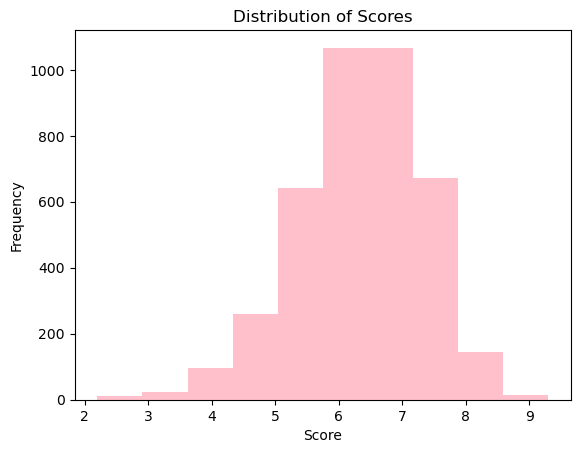

In [32]:
plt.hist(df["score"], bins=10, color='pink')

plt.title("Distribution of Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

In [ ]:
No. Most movies are moderately rated, with ratings concentrated between 6 and 7 rather than at the very high end (9–10).

Are low-rated movies common?

No. Low-rated movies appear less frequently than movies with average or above-average ratings.

What does the histogram tell you about movie ratings?

The histogram shows that movie ratings are concentrated around 6–7. Most movies receive average to good ratings, while very low and very high ratings are less common.